# Carbon-Credits — does buying 'the cap that only shrinks' pay? 🌍
### A green buy-and-hold bet, taken literally — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_timing_beat_buy--and--hold%3F: Not_supported](https://img.shields.io/badge/Does_timing_beat_buy--and--hold%3F-Not_supported-8b949e?style=flat-square)

The pitch is seductive: carbon allowances are the one asset where supply is *designed* to shrink. Every year the regulator retires permits, polluters still have to buy them, so the price 'can only go up' — just buy a carbon ETF like **KRBN** and ride the energy transition. This notebook takes that literally on KRBN's whole life (since 2020), asks the only question a *reward* has to answer — *did it beat just holding cash?* — and then tries the obvious fix: *what if you timed the trend instead of blindly holding?*

> **This is the plain-language layer.** Want the *t*-stats, the excess-of-cash Sharpe race and the bootstrap? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from carbon_credits import data, strategy as st

AS_OF_END = "2026-05-31"   # drop the partial June-2026 month

def _load_real():
    try:
        f = data.load_real(("KRBN", "BIL"), end=AS_OF_END)
        if len(f) < 200:
            return None
        return f
    except Exception as e:
        print("real tape unavailable (offline):", type(e).__name__)
        return None

REAL = _load_real()
HAVE_REAL = REAL is not None
print("real KRBN+BIL tape present:", HAVE_REAL)
if HAVE_REAL:
    print(f"  {REAL.index[0].date()} .. {REAL.index[-1].date()}  n={len(REAL)}  fp={data.fingerprint(REAL)}")


real KRBN+BIL tape present: True
  2020-07-31 .. 2026-05-29  n=1464  fp=cfb978f26c25


## The answer first

| Question | Answer |
|---|---|
| Did buy-and-hold carbon pay? | **It looks like it** — +16.2%/yr, a 2.4× over ~6 years. But measured against cash the edge is **not statistically real** (*t* = +1.41, below the bar). |
| Why the asterisk? | Because **one year did all the work.** 2021 was **+108%**; the other five years are a coin-flip around cash, with two double-digit *down* years. |
| Should you have timed it instead? | **No.** A 'hold only while the trend is up' overlay *lost* to simply holding — at every lookback, before costs, with worse drawdowns. |
| So what is it? | A volatile niche commodity dressed up as a one-way escalator. The green story is real; the **smooth compounding** is a story we tell after the one lucky year. |

> Carbon allowances may well rise over decades as caps tighten — the *economics* are sound. But a ~6-year, one-explosion tape can't prove a reward, and the 'just time it' rescue makes things worse, not better.

## 1 · The claim

> *"KRBN is the first US-listed ETF designed to track carbon-allowance markets. Under cap-and-trade, the supply of allowances is fixed and falling while polluters must keep buying — a structural tailwind. Carbon is a way to invest in the energy transition."*

— the KraneShares case for KRBN (paraphrased)

It rests on something genuinely real: the EU and other cap-and-trade systems **do** retire permits on a schedule, and the EU's Market Stability Reserve was built specifically to tighten supply and lift the floor. A shrinking supply meeting stubborn demand *should* push prices up over time. The bet is that you can just **hold** it and collect that drift.

## 2 · So what?

Two reasons to look hard. First, this is the rare 'folk' bet with a real mechanism behind it — so the interesting question isn't *whether carbon is a thing* (it is) but *whether a passive hold actually banked a reward, or just took a wild commodity ride that happened to end up*. Second, 'the cap only shrinks' is a perfect specimen of a **narrative that survives any single chart**: in a bull year it's vindicated, in a bear year it's 'temporary noise.' The only way to settle it is to measure the reward over cash, with honest error bars, and to ask whether the obvious active fix (timing) would have helped.

## 3 · How would we even know?

Three checks:

1. **Beat cash, not zero.** A 'reward' only counts if it beats parking the money in T-bills. We measure KRBN's average return *above cash* and ask whether it's distinguishable from luck.
2. **Where did the return come from?** We break it down year by year. If one year is the whole story, the 'steady escalator' framing is wrong.
3. **Would timing have helped?** We run the textbook fix — hold KRBN only while its recent trend is up, otherwise sit in cash — and race it against just holding, fairly (both measured above cash).

Tape: KRBN total-return daily bars from its 2020 launch, with BIL (T-bills) as the cash yardstick.

## 4 · The teardown — let's actually look

**First: the headline growth — and the one-year catch.** Here's KRBN's calendar-year total return:

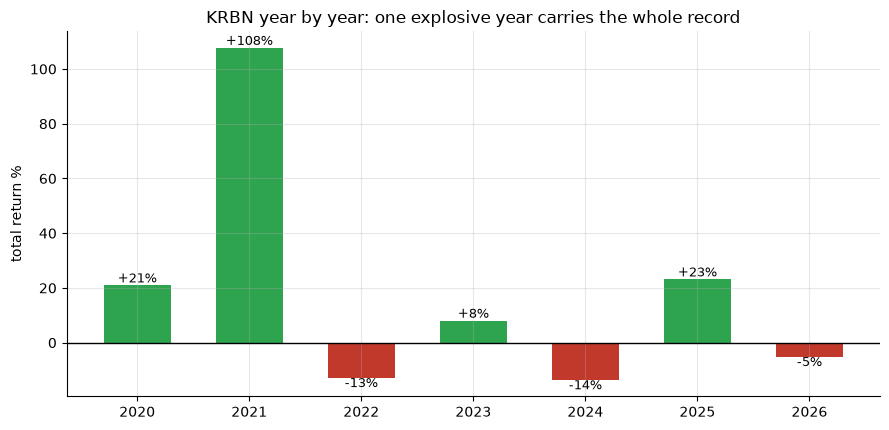

2021 alone: +108%   every other year averages near a coin-flip vs cash


In [2]:
if HAVE_REAL:
    Rr = st.to_returns(REAL)
    cy = Rr['KRBN'].groupby(Rr.index.year).apply(lambda s:(1+s).prod()-1)*100
    years = [int(y) for y in cy.index]; vals = list(cy.values)
else:
    years = [2020,2021,2022,2023,2024,2025,2026]
    vals = [20.9,107.7,-12.8,8.0,-13.6,23.1,-5.1]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [GREEN if v>=0 else RED for v in vals]
b = ax.bar([str(y) for y in years], vals, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('total return %')
ax.set_title('KRBN year by year: one explosive year carries the whole record')
for bar_, v in zip(b, vals):
    ax.annotate(f'{v:+.0f}%', (bar_.get_x()+bar_.get_width()/2, v),
        ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print('2021 alone:', f'{vals[1]:+.0f}%   every other year averages near a coin-flip vs cash')

There's the whole study in one chart. **2021 was +108%** (EU allowances ripped on tighter climate targets and a gas-supply crunch). Take that year away and what's left is two double-digit *losses* (2022, 2024), a couple of modest gains, and a flat year — a volatile commodity, not an escalator.

**Second: did the hold actually beat cash?** Growth means nothing if it doesn't clear the risk-free bar. Here's the average daily edge over T-bills, with its honest *t*-stat:

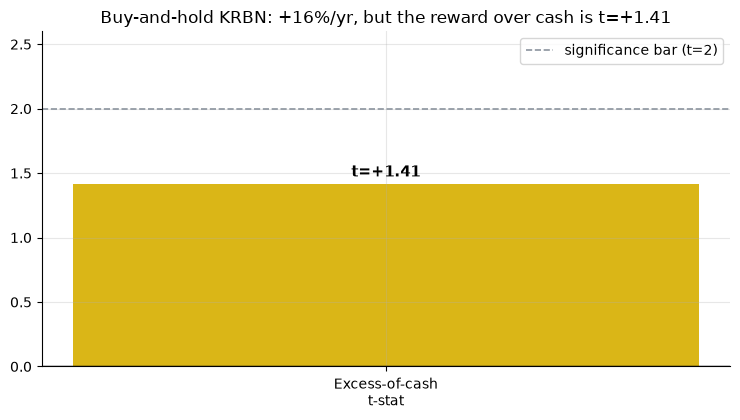

CAGR +16.2%/yr, Sharpe(ex-cash) 0.57, max drawdown -36% — but t=+1.41 (below 2)


In [3]:
if HAVE_REAL:
    Rr = st.to_returns(REAL); rf = Rr['BIL']; bh = st.buy_and_hold(Rr)
    s = st.stats(bh, rf); t = st.excess_tstat(bh, rf)
    cagr, sharpe, maxdd = s['cagr']*100, s['sharpe'], s['max_dd']*100
else:
    cagr, sharpe, maxdd, t = 16.2, 0.57, -36.4, 1.41
fig, ax = plt.subplots(figsize=(7.5, 4.3))
b = ax.bar(['Excess-of-cash\nt-stat'], [t], color=AMBER if abs(t)<2 else GREEN, width=.4)
ax.axhline(2, ls='--', c=GREY, lw=1.2, label='significance bar (t=2)')
ax.axhline(0, c='k', lw=1); ax.set_ylim(0, 2.6); ax.legend()
ax.set_title(f'Buy-and-hold KRBN: +{cagr:.0f}%/yr, but the reward over cash is t={t:+.2f}')
ax.annotate(f't={t:+.2f}', (0, t+0.06), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'CAGR {cagr:+.1f}%/yr, Sharpe(ex-cash) {sharpe:.2f}, max drawdown {maxdd:.0f}% — but t={t:+.2f} (below 2)')

The compounding is real (+16%/yr), but the **reward over cash is *t* = +1.41** — under the significance bar. With 29% volatility and a −36% drawdown over a single market cycle, you genuinely cannot tell this apart from an expensive way of holding cash. The economics may be sound; this *tape* can't prove the payoff.

**Third: would timing have saved it?** The textbook rescue is *don't blindly hold — hold only while the trend is up, otherwise go to cash.* Here's that overlay (6-month trend) against just holding:

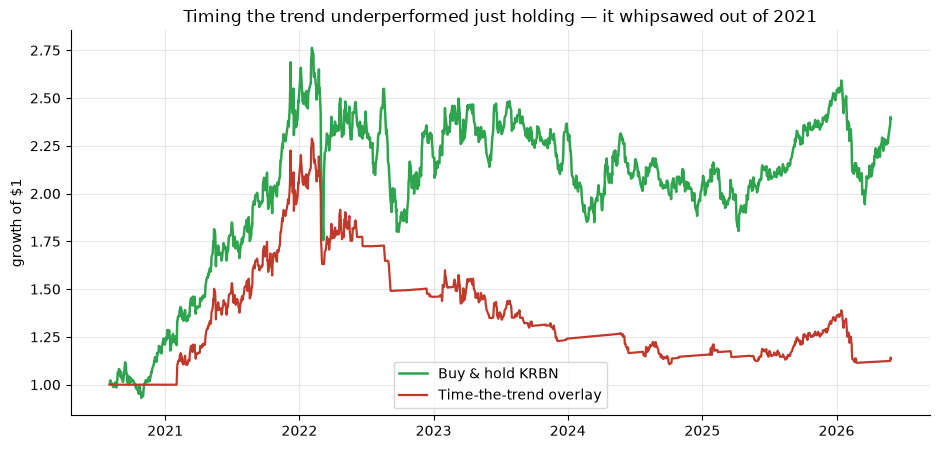

6-month overlay: ~2%/yr vs buy-and-hold ~16%/yr — timing LOST


In [4]:
if HAVE_REAL:
    Rr = st.to_returns(REAL); rf = Rr['BIL']; bh = st.buy_and_hold(Rr)
    sig = st.momentum_signal(REAL, 'KRBN', lookback=126)
    ov = st.overlay_returns(Rr, sig, 'KRBN', 'BIL', cost_bps=0.0)
    eq_bh = (1+bh).cumprod(); eq_ov = (1+ov).cumprod()
    idx = eq_bh.index
else:
    idx = pd.bdate_range('2020-07-31', periods=1464)
    rng = np.random.default_rng(0)
    eq_bh = pd.Series(np.exp(np.cumsum(rng.normal(0.0006,0.018,len(idx)))), index=idx)
    eq_ov = pd.Series(np.exp(np.cumsum(rng.normal(0.0001,0.012,len(idx)))), index=idx)
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.plot(idx, eq_bh.values, c=GREEN, lw=1.8, label='Buy & hold KRBN')
ax.plot(idx, eq_ov.values, c=RED, lw=1.6, label='Time-the-trend overlay')
ax.set_ylabel('growth of $1'); ax.legend()
ax.set_title('Timing the trend underperformed just holding — it whipsawed out of 2021')
plt.tight_layout(); plt.show()
print('6-month overlay: ~2%/yr vs buy-and-hold ~16%/yr — timing LOST')

The overlay sits in cash through part of the 2021 melt-up and keeps flipping in the choppy years — it earned ~+2%/yr against buy-and-hold's +16%/yr, with a *deeper* drawdown. The fix that's supposed to tame a volatile asset made it worse.

## 5 · The verdict

- **Signal — Weak.** +16%/yr looks great, but the reward over cash is *t* = +1.41 (below the bar) and one year (2021, +108%) is the whole record. The cap-shrinks economics are real; this tape can't certify a payoff.
- **Tradability — Mirage.** A 29%-vol, −36%-drawdown commodity whose Sharpe over cash is indistinguishable from cash — and the obvious active overlay makes it *worse*. No risk-adjusted edge to harvest.
- **Does timing beat buy-and-hold? — Not supported.** The trend overlay lost to naive holding at every lookback, before costs. Doing nothing beat trying to time it.

## 6 · Could you actually trade it?

You *can* trade KRBN — it's liquid enough. The problem isn't access, it's that there's no edge on either side. Buy-and-hold is just expensive beta on a niche commodity; the trend overlay trades a lot (dozens of in/out flips) to earn *less*. The honest pitch isn't 'a one-way green compounding machine' or 'a timeable trend' — it's 'a volatile thematic exposure you might hold for conviction reasons, knowing the smooth-escalator story is mostly survivorship of one good year.'

## 7 · Going further

- **Longer history.** KRBN is only ~6 years old. The underlying EU allowance futures go back to 2008 — a longer tape (with the 2008 and 2018 regime shifts) might finally clear the bar, or finally bury it.
- **Carry, not spot.** KRBN holds *futures*; roll yield (contango/backwardation) is a separate driver from spot allowance prices. A carry decomposition is the next fork.
- **The sister studies.** This is the same buy-and-hold-vs-alternative machinery as [Study 97 — Balancing-Act](../../97-balancing-act/) (60/40) and the same single-cycle-commodity caution as [Study 152 — Inflation-Hedge](../../152-inflation-hedge/).

*Think the cap-and-trade tailwind is real and just needs more data? Fork this, wire in the long EUA futures tape, and show the reward-over-cash clearing t = 2.*